## **PROJECT 3 :- CNN (MNIST Dataset)**

In [1]:
# Import NumPy, plotting tools, MNIST data, and CNN layers.
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

In [2]:
# Load the MNIST handwritten digit training and testing data.
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


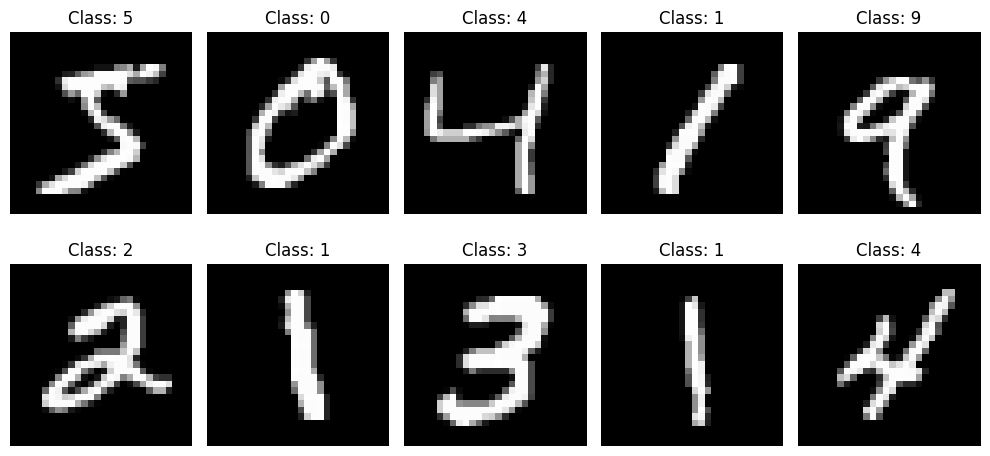

In [3]:
# Display sample MNIST images with their corresponding class labels.
plt.figure(figsize=(10, 5))
for idx in range(10):
    plt.subplot(2, 5, idx + 1)
    plt.imshow(train_images[idx], cmap='gray')
    plt.title(f"Class: {train_labels[idx]}")
    plt.axis("off")
plt.tight_layout()
plt.show()


In [4]:
# Normalize and reshape image data for convolutional neural network input.
train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

train_images = train_images.reshape(-1, 28, 28, 1)
test_images = test_images.reshape(-1, 28, 28, 1)

In [5]:
# Define the CNN architecture for handwritten digit classification.
cnn_model = Sequential([
    Input(shape=(28, 28, 1)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

In [6]:
# Compile the CNN with Adam optimizer and sparse categorical loss.
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
# Train the CNN model using a validation split for progress monitoring.
training_history = cnn_model.fit(
    train_images, train_labels,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 50ms/step - accuracy: 0.9368 - loss: 0.2046 - val_accuracy: 0.9809 - val_loss: 0.0665
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - accuracy: 0.9818 - loss: 0.0574 - val_accuracy: 0.9868 - val_loss: 0.0495
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.9883 - loss: 0.0393 - val_accuracy: 0.9868 - val_loss: 0.0469
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 37s 49ms/step - accuracy: 0.9906 - loss: 0.0293 - val_accuracy: 0.9875 - val_loss: 0.0417
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 53ms/step - accuracy: 0.9930 - loss: 0.0227 - val_accuracy: 0.9881 - val_loss: 0.0423


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9899 - loss: 0.0293
Final Test Accuracy: 0.9899


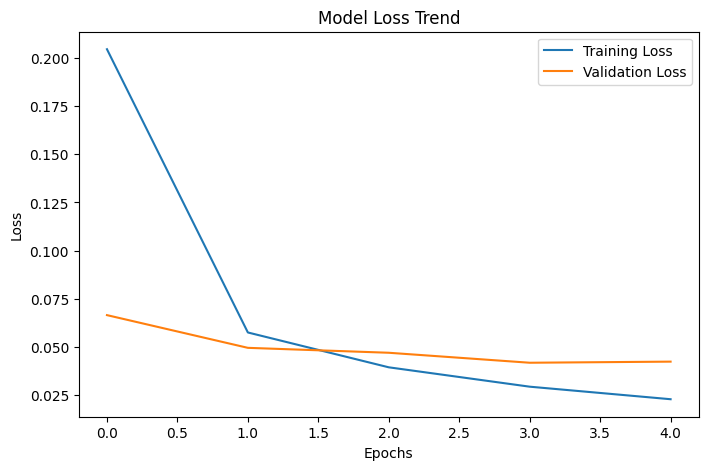

In [8]:
# Evaluate test accuracy and plot the loss curves after training.
test_loss, test_accuracy = cnn_model.evaluate(test_images, test_labels)
print("Final Test Accuracy:", round(test_accuracy, 4))

plt.figure(figsize=(8, 5))
plt.plot(training_history.history['loss'], label='Training Loss')
plt.plot(training_history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss Trend")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


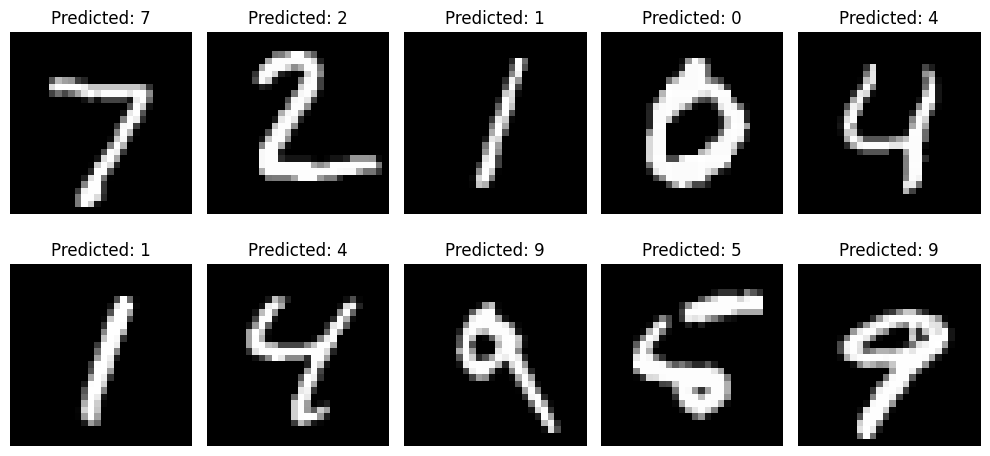

In [9]:
# Generate predictions and visualize sample predicted digit classes.
predictions = cnn_model.predict(test_images)

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(test_images[i].reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {np.argmax(predictions[i])}")
    plt.axis('off')

plt.tight_layout()
plt.show()